<a href="https://colab.research.google.com/github/23118018/SPPU-GPA-Calcs/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  

**Project Theme:** Seasonal Agriculture Performance  

**Tools Used:**  
Python, Pandas, NumPy, Matplotlib and Seaborn

## 🎯 Project Goal

This project analyzes agricultural performance  
across different seasons.

The objective is to identify:

- Seasonal patterns
- Performance trends
- Important relationships
- Differences in agricultural outcomes

The analysis uses Data Analytics and  
Exploratory Data Analysis techniques.

# 1. Problem Statement

Agricultural activities are influenced by seasonal variations.

These variations can affect:

- Environmental conditions
- Farming practices
- Resource availability
- Economic performance

As a result, agricultural performance may vary  
from one season to another.

This project analyzes the agricultural dataset to identify:

- Patterns
- Trends
- Relationships
- Seasonal variations

The findings will help understand how agricultural  
performance changes across different seasons.

# Step 2: Data Understanding and Data Cleaning

In this step, the dataset is examined  
to understand its quality and structure.

The following checks will be performed:

- Missing values
- Duplicate records
- Data types
- Data cleaning

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load Dataset

In [58]:
df = pd.read_csv(
    "seasonal_agriculture_performance_dataset.csv"
)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Dataset Overview

In [59]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 4000
Columns: 28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha           

In [60]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 3. Data Quality Check

In [61]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [62]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


## 4. Data Cleaning

In [63]:
missing_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in missing_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Missing values handled successfully.")

Missing values handled successfully.


In [64]:
df.drop_duplicates(inplace=True)

print("Duplicate Records After Cleaning:",
      df.duplicated().sum())

Duplicate Records After Cleaning: 0


In [65]:
print("Total Missing Values:",
      df.isnull().sum().sum())

print("Dataset Shape:", df.shape)

Total Missing Values: 0
Dataset Shape: (4000, 28)


## 5. Exploratory Data Analysis

### 5.1 Season Distribution

In [66]:
season_counts = df["Season"].value_counts()

season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


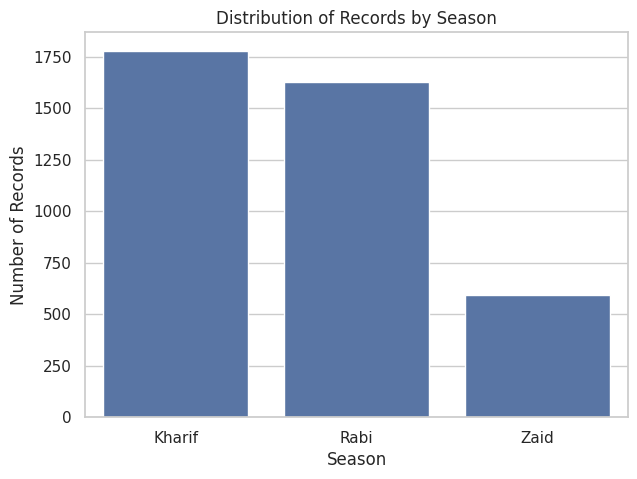

In [67]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

### 5.2 Seasonal Agricultural Performance

In [68]:
season_performance = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

season_performance

,Average_Yield,Total_Production,Average_Revenue,Average_Profit
Season,,,,
Kharif,5.63,82387.61,710719.06,178914.65
Rabi,5.04,67498.88,601526.05,87689.47
Zaid,4.64,23098.35,519171.90,-24804.82


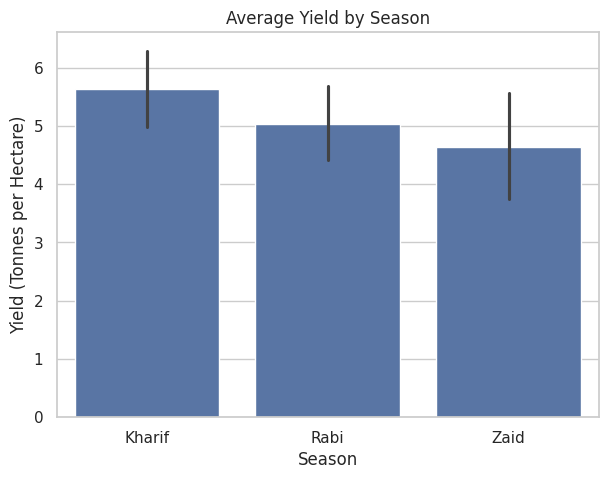

In [69]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.show()

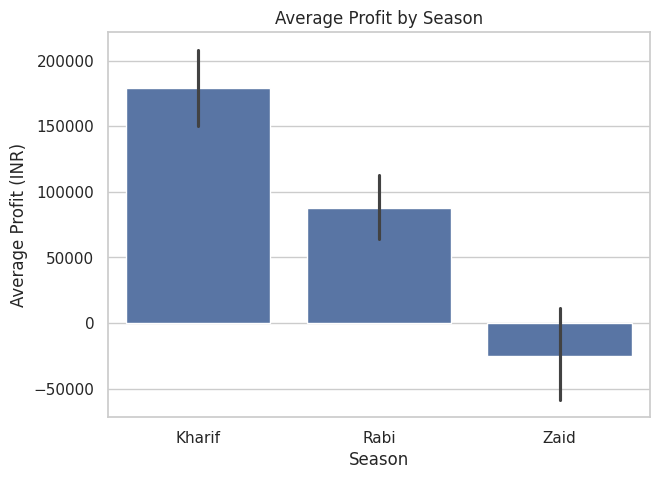

In [70]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

## 6. Environmental Analysis

### 6.1 Environmental Conditions by Season

In [71]:
environmental_analysis = df.groupby("Season").agg(
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Humidity=("Humidity_pct", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean")
).round(2)

environmental_analysis

,Average_Rainfall,Average_Temperature,Average_Humidity,Average_Soil_Moisture
Season,,,,
Kharif,849.20,28.45,71.81,31.15
Rabi,437.62,23.49,57.89,24.07
Zaid,304.65,31.04,52.01,19.28


### 6.2 Average Rainfall by Season

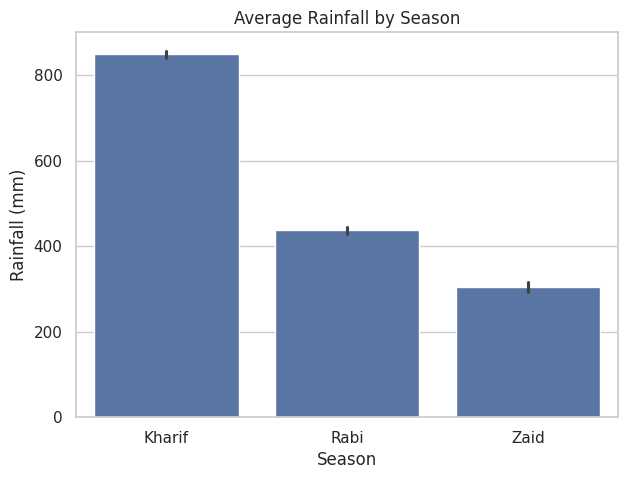

In [72]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

### 6.3 Average Temperature by Season

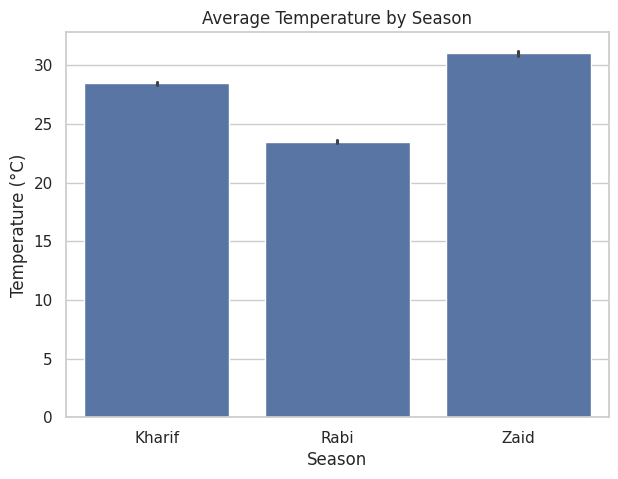

In [73]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.show()

### 6.4 Average Soil Moisture by Season

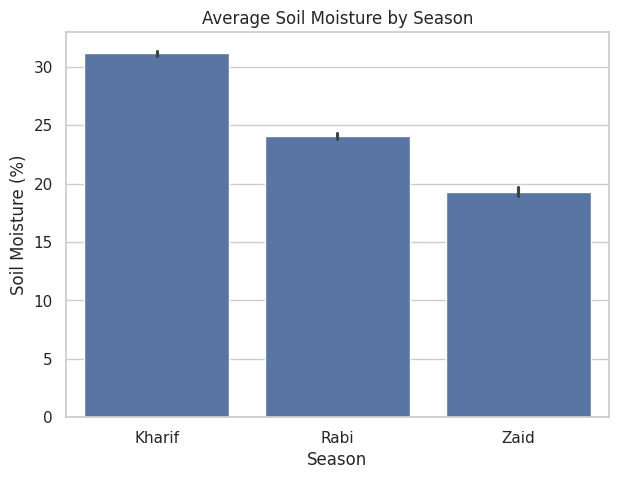

In [74]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Soil_Moisture_pct"
)

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.show()

### 6.5 Average Humidity by Season

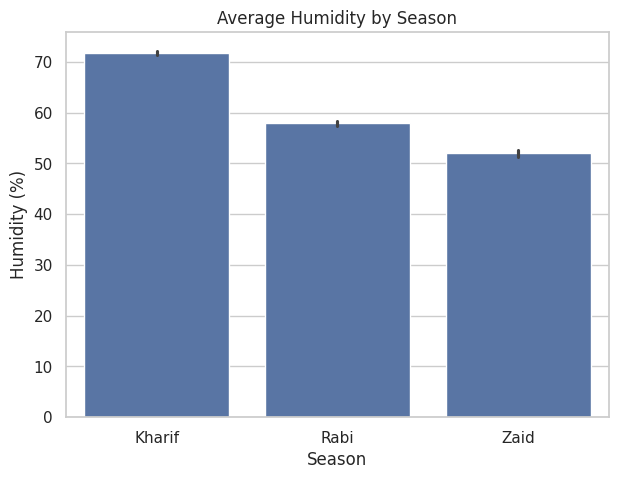

In [75]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Humidity_pct"
)

plt.title("Average Humidity by Season")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")

plt.show()

## 7. Crop Performance Analysis

### 7.1 Crop Performance Summary

In [76]:
crop_performance = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

crop_performance.sort_values(
    by="Average_Profit",
    ascending=False
)

,Average_Yield,Total_Production,Average_Profit
Crop,,,
Sugarcane,46.64,119685.97,817187.99
Chilli,1.54,5101.75,750878.34
Cotton,1.23,4773.10,124546.92
Groundnut,1.32,4094.07,44858.12
Pulses,0.92,3671.10,-4238.05
Maize,2.71,12001.40,-83978.33
Rice,2.43,13309.15,-102213.50
Wheat,2.11,10348.30,-123398.34


### 7.2 Average Yield by Crop

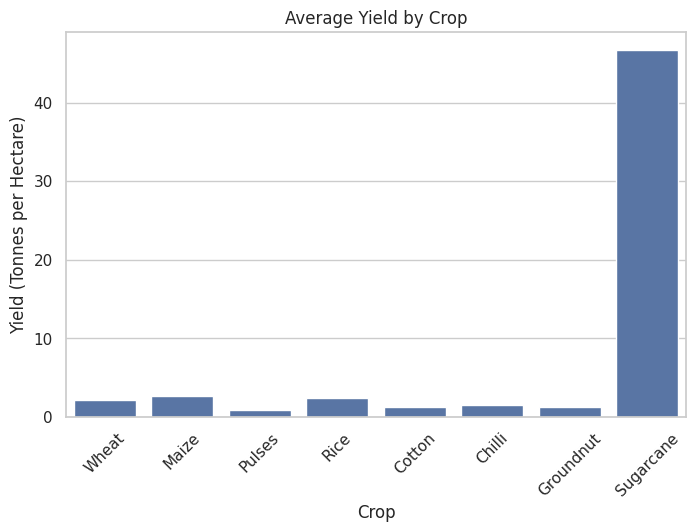

In [77]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.xticks(rotation=45)

plt.show()

### 7.3 Total Production by Crop

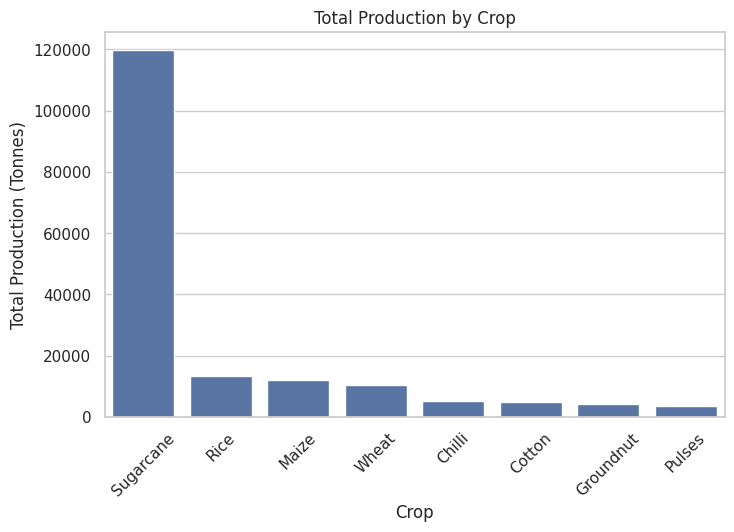

In [78]:
crop_production = (
    df.groupby("Crop")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=crop_production.index,
    y=crop_production.values
)

plt.title("Total Production by Crop")
plt.xlabel("Crop")
plt.ylabel("Total Production (Tonnes)")

plt.xticks(rotation=45)

plt.show()

### 7.4 Average Profit by Crop

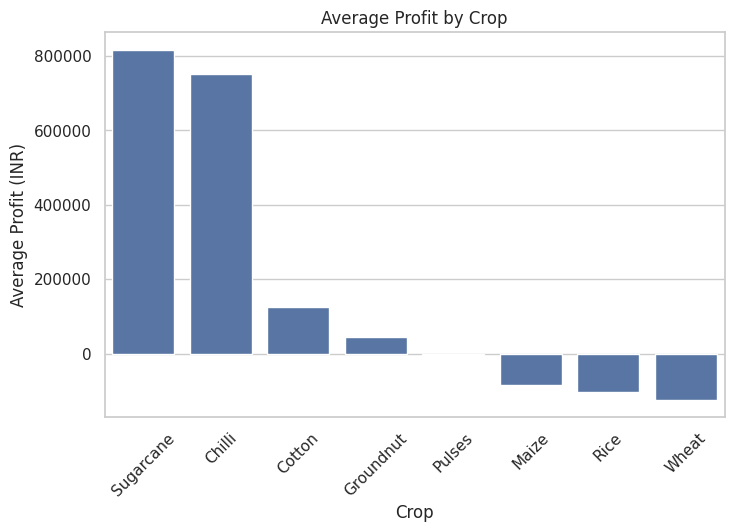

In [79]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=crop_profit.index,
    y=crop_profit.values
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=45)

plt.show()

### 7.5 Crop Yield Across Seasons

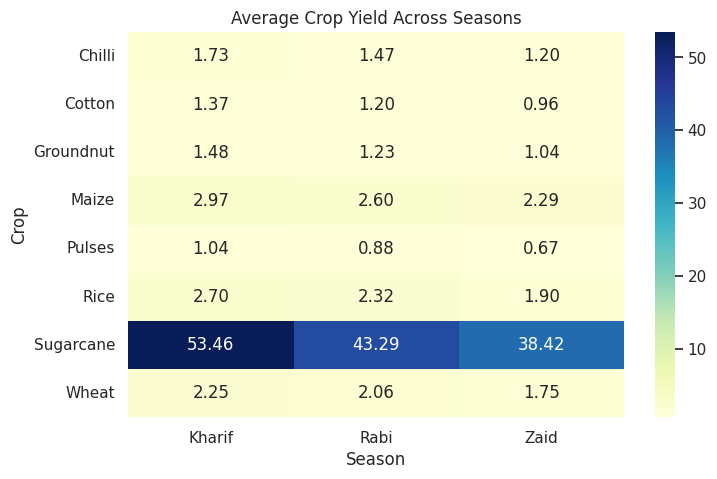

In [80]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")

plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

## 8. Irrigation and Water Efficiency Analysis

### 8.1 Irrigation Performance Summary

In [81]:
irrigation_analysis = df.groupby(
    "Irrigation_Method"
).agg(
    Average_Water_Used=(
        "Water_Used_m3",
        "mean"
    ),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),
    Average_Yield=(
        "Yield_Tonnes_Ha",
        "mean"
    )
).round(2)

irrigation_analysis

,Average_Water_Used,Average_Water_Efficiency,Average_Yield
Irrigation_Method,,,
Drip,5918.75,6.27,6.58
Flood,8026.47,3.44,4.86
Rainfed,3549.55,7.56,4.60
Sprinkler,6208.26,4.67,5.16


### 8.2 Average Water Used by Irrigation Method

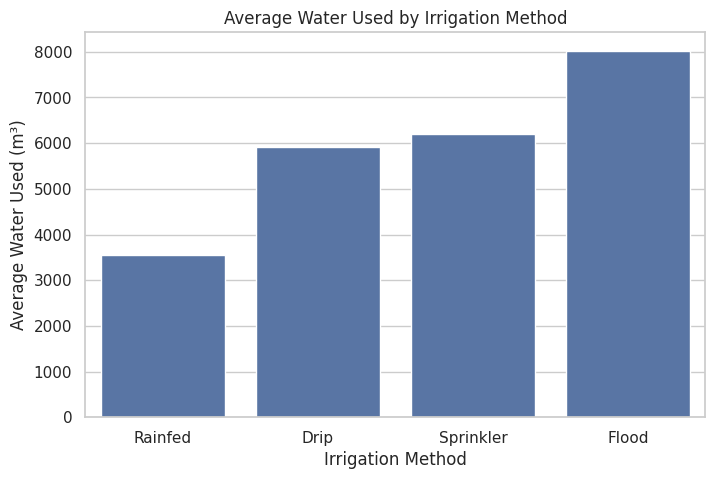

In [82]:
water_used = (
    df.groupby("Irrigation_Method")["Water_Used_m3"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_used.index,
    y=water_used.values
)

plt.title("Average Water Used by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Water Used (m³)")

plt.show()

### 8.3 Water Efficiency by Irrigation Method

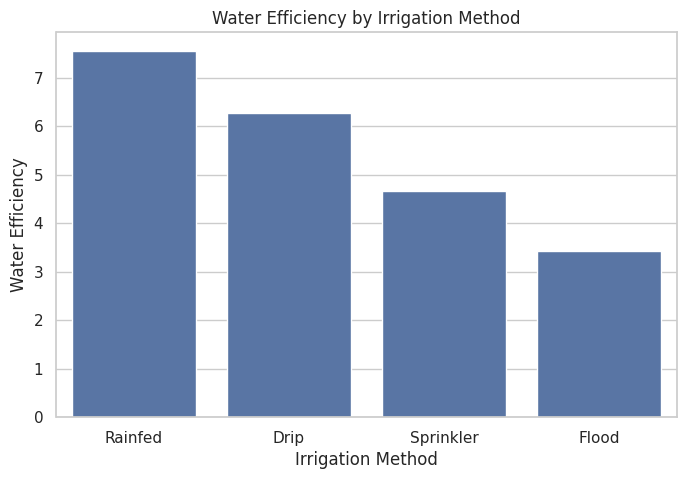

In [83]:
water_efficiency = (
    df.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.show()

### 8.4 Average Yield by Irrigation Method


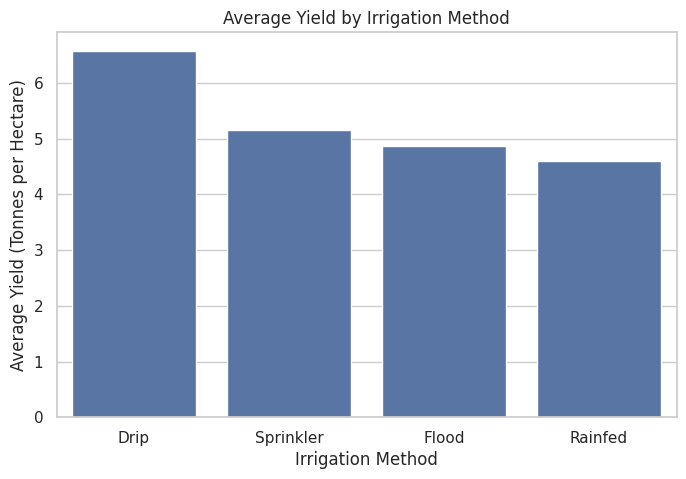

In [84]:
irrigation_yield = (
    df.groupby("Irrigation_Method")
    ["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes per Hectare)")

plt.show()

## 9. Economic Performance Analysis

### 9.1 Economic Performance by Season

In [85]:
economic_analysis = df.groupby("Season").agg(
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

economic_analysis

,Average_Cost,Average_Revenue,Average_Profit
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


### 9.2 Average Revenue by Season

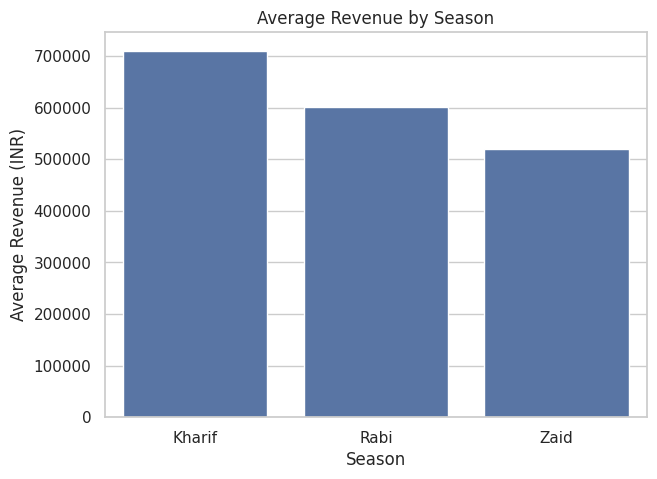

In [86]:
season_revenue = (
    df.groupby("Season")["Revenue_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")

plt.show()

### 9.3 Average Cost by Season

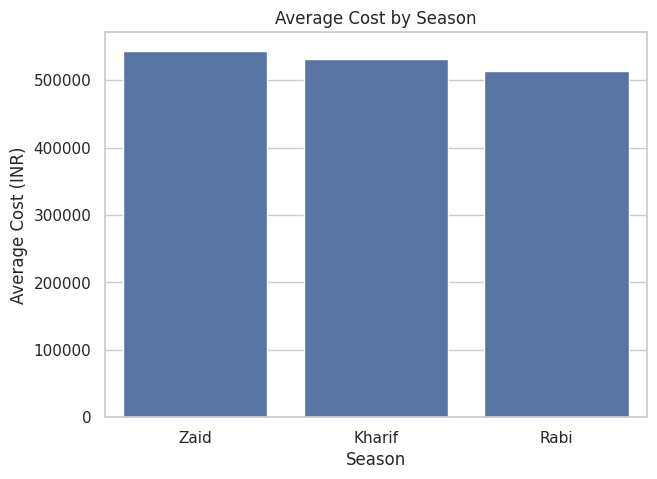

In [87]:
season_cost = (
    df.groupby("Season")["Total_Cost_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=season_cost.index,
    y=season_cost.values
)

plt.title("Average Cost by Season")
plt.xlabel("Season")
plt.ylabel("Average Cost (INR)")

plt.show()

### 9.4 Average Profit by Season

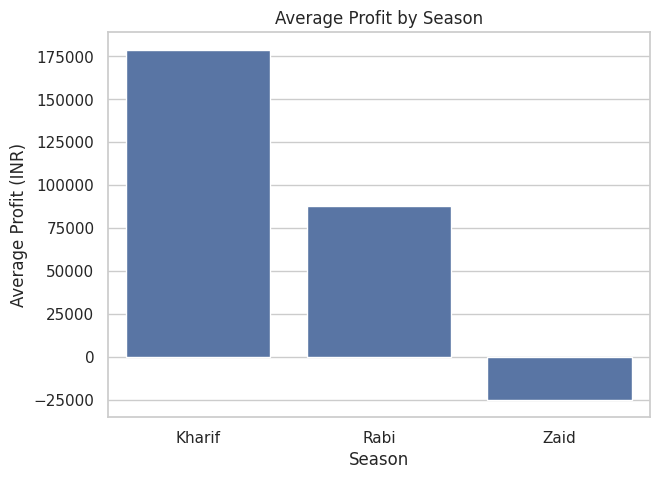

In [88]:
season_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

### 9.5 Revenue vs Cost

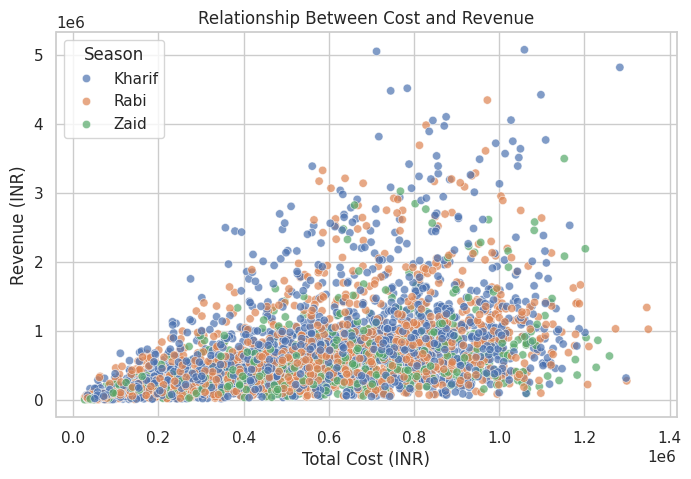

In [89]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Cost_INR",
    y="Revenue_INR",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Cost and Revenue")
plt.xlabel("Total Cost (INR)")
plt.ylabel("Revenue (INR)")

plt.show()

## 10. State-wise Performance Analysis

### 10.1 State-wise Performance Summary

In [90]:
state_performance = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

state_performance.sort_values(
    by="Average_Profit",
    ascending=False
)

,Average_Yield,Total_Production,Average_Profit
State,,,
Punjab,6.12,25280.82,136025.64
Maharashtra,5.02,22519.83,135428.86
Karnataka,5.69,23341.30,119422.34
Tamil Nadu,4.88,19807.58,117744.75
Gujarat,5.66,23586.01,117568.24
Telangana,5.04,20255.16,108829.62
Madhya Pradesh,4.99,18667.08,86840.76
Andhra Pradesh,4.63,19527.06,73453.53


### 10.2 Average Yield by State

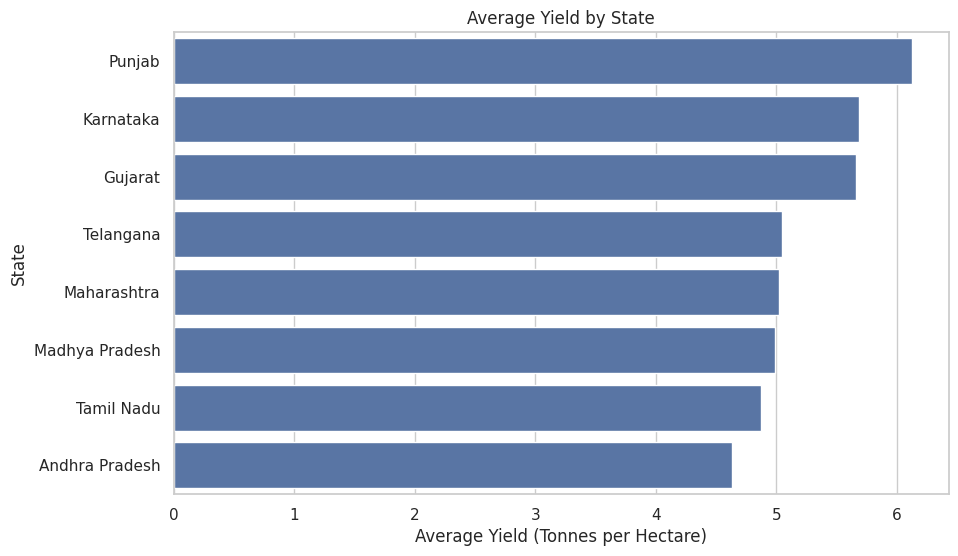

In [91]:
state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title("Average Yield by State")
plt.xlabel("Average Yield (Tonnes per Hectare)")
plt.ylabel("State")

plt.show()

### 10.3 Total Production by State

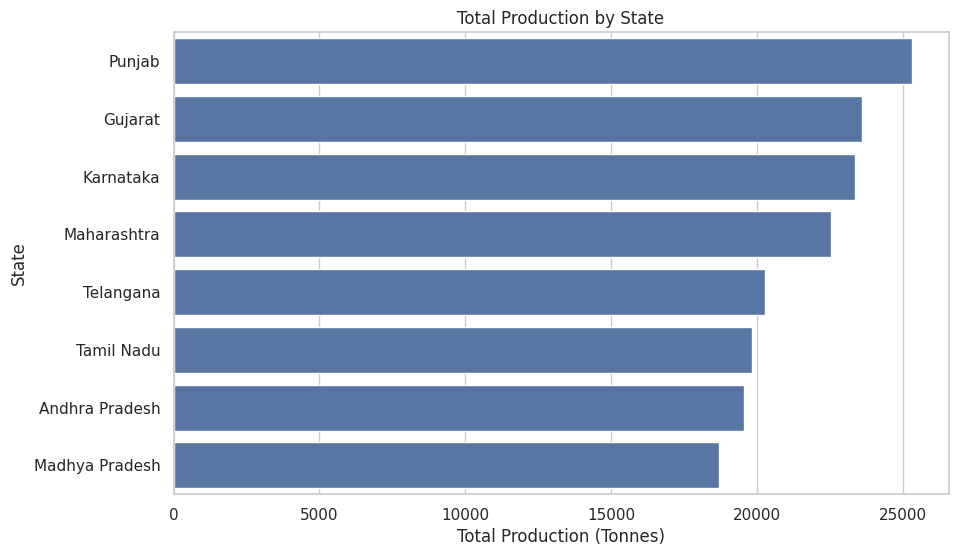

In [92]:
state_production = (
    df.groupby("State")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_production.values,
    y=state_production.index
)

plt.title("Total Production by State")
plt.xlabel("Total Production (Tonnes)")
plt.ylabel("State")

plt.show()

### 10.4 Average Profit by State

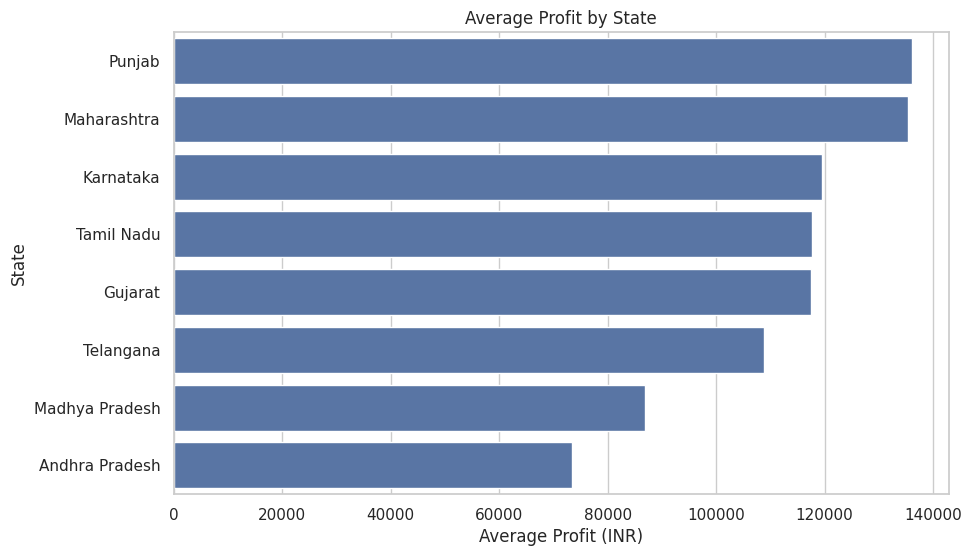

In [93]:
state_profit = (
    df.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")

plt.show()

## 11. Relationship and Correlation Analysis

### 11.1 Correlation Analysis

In [94]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR"
]

correlation_data = df[correlation_columns]

correlation_data.corr().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.51,0.00,0.03,0.02,0.10,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,0.01,0.03,0.01
Humidity_pct,0.52,0.14,1.00,0.45,-0.00,0.01,0.00,0.06,0.06
Soil_Moisture_pct,0.51,0.08,0.45,1.00,0.00,0.01,0.00,0.08,0.09
Water_Used_m3,0.00,0.02,-0.00,0.00,1.00,0.39,0.52,0.43,0.19
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,0.39,1.00,0.88,0.43,0.49
Production_Tonnes,0.02,0.01,0.00,0.00,0.52,0.88,1.00,0.56,0.55
Revenue_INR,0.10,0.03,0.06,0.08,0.43,0.43,0.56,1.00,0.89
Profit_INR,0.11,0.01,0.06,0.09,0.19,0.49,0.55,0.89,1.00


### 11.2 Correlation Heatmap

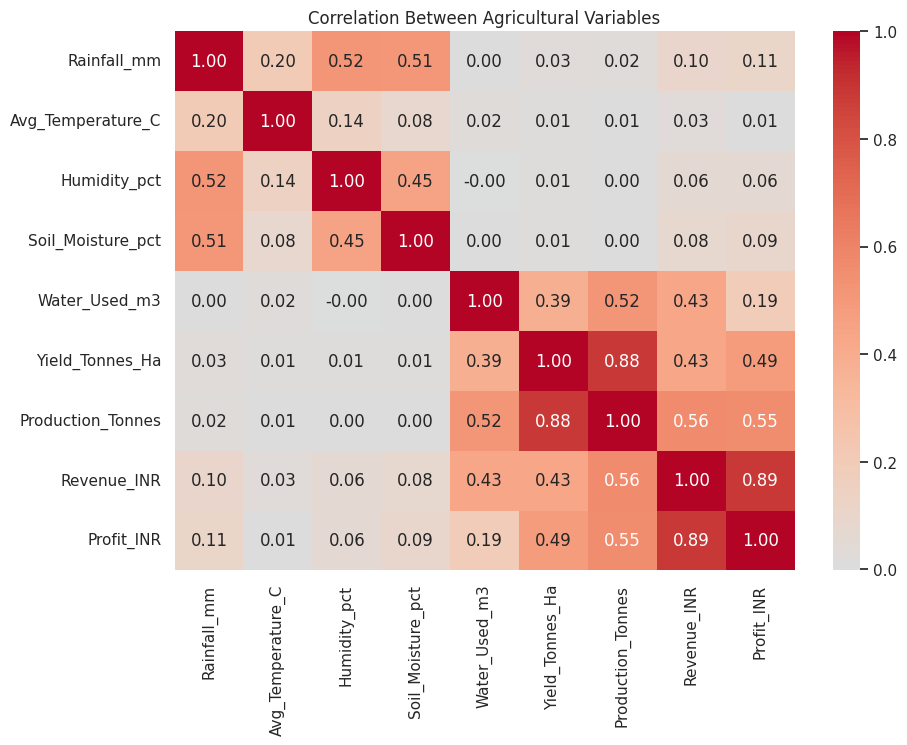

In [95]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Agricultural Variables")

plt.show()

### 11.3 Rainfall vs Yield

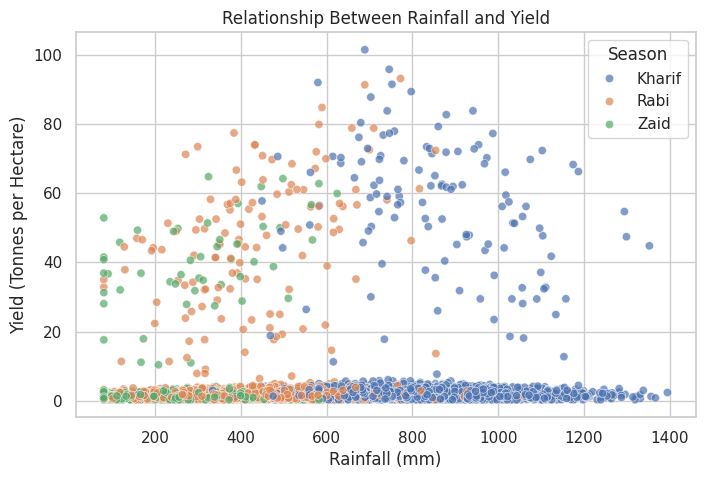

In [96]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.show()

### 11.4 Water Usage vs Yield

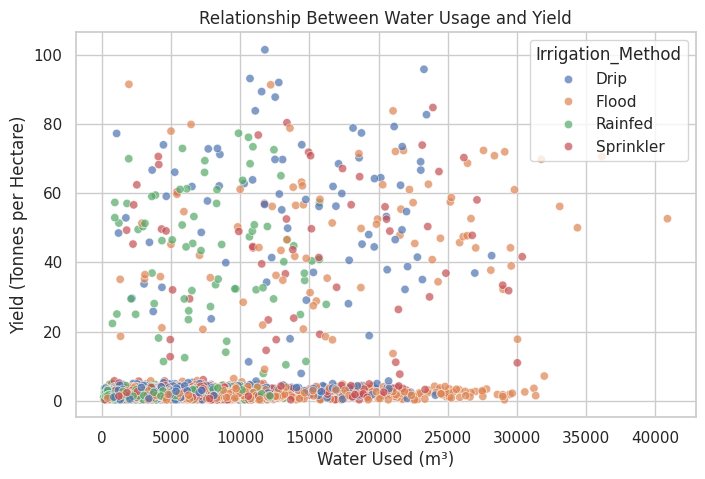

In [97]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method",
    alpha=0.7
)

plt.title("Relationship Between Water Usage and Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.show()

### 11.5 Revenue vs Profit

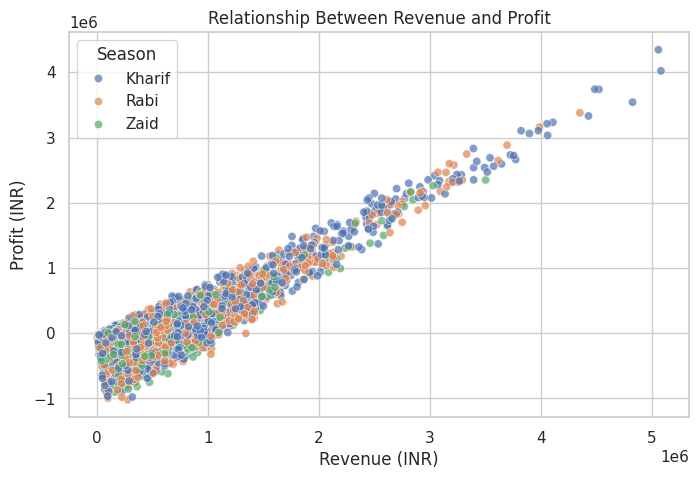

In [98]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Revenue_INR",
    y="Profit_INR",
    hue="Season",
    alpha=0.7
)

plt.title("Relationship Between Revenue and Profit")
plt.xlabel("Revenue (INR)")
plt.ylabel("Profit (INR)")

plt.show()

## 12. Key Insights and Recommendations

### 12.1 Key Insights

Based on the analysis, the following key insights were identified:

- Agricultural performance varies across different seasons.

- Environmental factors such as rainfall,
  temperature, humidity and soil moisture
  show seasonal variations.

- Crop performance differs based on
  yield, production and profitability.

- Irrigation methods show differences in
  water usage and water efficiency.

- Economic performance varies across seasons
  in terms of cost, revenue and profit.

- State-wise analysis highlights differences
  in agricultural performance across regions.

- Correlation analysis identifies relationships
  between environmental, production and
  economic variables.

### 12.2 Recommendations

Based on the analysis, the following
recommendations can be considered:

- Select suitable crops according to
  seasonal conditions.

- Improve water management practices
  to increase water efficiency.

- Promote efficient irrigation methods
  where appropriate.

- Monitor environmental conditions such as
  rainfall and soil moisture.

- Focus on improving agricultural practices
  in lower-performing regions.

- Use data-driven planning to improve
  production and profitability.

- Regularly monitor important factors that
  influence agricultural performance.

## 13. Conclusion

This project analyzed seasonal agricultural performance
using data analysis and visualization techniques.

The analysis examined:

- Seasonal performance
- Environmental conditions
- Crop performance
- Irrigation and water efficiency
- Economic performance
- State-wise performance
- Relationships between important variables

The results demonstrate that agricultural performance
can vary across seasons, crops and regions.

The analysis provides useful insights that can support
data-driven agricultural planning and decision-making.

## 14. Future Scope

Future improvements to this project may include:

- Predicting future agricultural yield
- Building machine learning models
- Forecasting agricultural production
- Predicting profitability
- Including real-time weather data
- Creating an interactive dashboard
- Developing a crop recommendation system

These improvements could help transform the analysis
into a more advanced decision-support system.